# Driving-Style Clustering Workbench

This notebook fits clustering models directly on the extracted feature table. Use it to test whether any kinematic feature set produces sensible driving-style clusters and whether those clusters help identify hard samples.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = Path('/fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction')
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from tailrisk_mp.clustering_workbench import (
    DRIVING_STYLE_FEATURE_SETS,
    TRAJECTORY_LABELS,
    compute_projection,
    fit_cluster_result,
    leave_one_feature_out_importance,
    representative_examples,
    run_feature_sweep,
    separation_feature_importance,
)
from tailrisk_mp.scenario_viz import load_scenario_by_id, plot_scenario

sns.set_theme(style='whitegrid')
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts'

def resolve_artifact_root(name: str) -> Path:
    path = ARTIFACTS_ROOT / name
    if not path.exists():
        raise FileNotFoundError(f'Artifact root not found: {path}')
    return path

def resolve_feature_names(frame: pd.DataFrame, config: dict):
    override = [name for name in config.get('feature_names_override', []) if name in frame.columns]
    if override:
        return override
    return [name for name in DRIVING_STYLE_FEATURE_SETS[config['feature_set_name']] if name in frame.columns]


In [66]:
CONFIG = {
    'artifact_root': 'day2_train20',
    'dataset': 'av2',
    'split': 'train',
    'error_column': 'mtr_minfde6',
    'feature_set_name': 'style_full',
    'feature_names_override': [],
    'method': 'agglomerative',
    'transform': 'mixed_robust',
    'clip_mode': 'none',
    'n_clusters': 2,
    'drop_stationary': True,
    'feature_sweep_methods': ['kmeans', 'gmm', 'agglomerative'],
    'feature_sweep_transforms': ['mixed_robust', 'mixed_clip8', 'quantile_normal'],
    'feature_sweep_clip_modes': ['none', 'clip8'],
    'feature_sweep_cluster_counts': [3, 4, 5],
    'cluster_id': 0,
    'example_mode': 'nearest',
    'example_rank': 0,
    'scenario_id': None,
    'tsne_sample_limit': 3000,
    'view_radius': 90.0,
}


In [67]:
ARTIFACT_ROOT = resolve_artifact_root(CONFIG['artifact_root'])
TABLE_ROOT = ARTIFACT_ROOT / 'tables'
table_path = TABLE_ROOT / f"{CONFIG['dataset']}_{CONFIG['split']}_feature_table.csv"
df = pd.read_csv(table_path)
preferred_errors = ['mtr_minfde6', 'mtr_brier_minfde6', 'mtr_minade6', 'cv_fde', 'cv_ade']
if CONFIG['error_column'] not in df.columns:
    CONFIG['error_column'] = next((c for c in preferred_errors if c in df.columns), CONFIG['error_column'])
df['trajectory_label'] = df['trajectory_type'].map(lambda x: TRAJECTORY_LABELS.get(int(x), str(x)))
if CONFIG.get('drop_stationary', True):
    df = df[df['trajectory_label'] != 'stationary'].copy()
feature_names = resolve_feature_names(df, CONFIG)
display(Markdown(f"**Artifact root:** `{CONFIG['artifact_root']}`  \
**Table:** `{table_path.name}`  \
**Rows:** {len(df):,}  \
**Feature set:** `{CONFIG['feature_set_name']}`  \
**Features:** {feature_names}  \
**Active error column:** `{CONFIG['error_column']}`"))
df.head()

**Artifact root:** `day2_train20`  **Table:** `av2_train_feature_table.csv`  **Rows:** 34,145  **Feature set:** `style_full`  **Features:** ['avg_speed', 'max_speed', 'var_speed', 'avg_accel', 'max_accel', 'max_abs_accel', 'var_acceleration', 'avg_jerk', 'max_abs_jerk', 'avg_long_accel', 'max_abs_long_accel', 'avg_lat_accel', 'max_abs_lat_accel', 'avg_long_jerk', 'max_abs_long_jerk', 'avg_lat_jerk', 'max_abs_lat_jerk', 'displacement', 'path_length', 'heading_change_signed', 'max_abs_heading_delta', 'max_abs_heading_rate', 'curvature_signed', 'gamma']  **Active error column:** `mtr_minfde6`

,dataset,split,scenario_id,center_objects_id,center_objects_type,trajectory_type,kalman_difficulty_2s,kalman_difficulty_4s,kalman_difficulty_6s,avg_speed,...,mtr_minade6,mtr_minfde6,mtr_brier_minade6,mtr_brier_minfde6,mtr_miss_rate,mtr_meanfde6_weighted,mtr_meanfde6_unweighted,mtr_best_mode_prob,mtr_best_fde_mode_idx,trajectory_label
0,av2,train,5ad5923b-f4ca-4dd5-be60-34025f9d6fa2,217734,1,1,3.126461,2.319344,0.463471,5.366892,...,0.616728,0.172729,0.670732,0.226732,0.0,1.386502,7.901772,0.767614,0.0,straight
1,av2,train,c696418a-385f-4749-8c5e-90956f45b231,82685,1,1,5.585094,15.066976,27.834641,6.629729,...,0.305317,1.105650,0.456390,1.256723,0.0,2.199339,12.160145,0.611319,0.0,straight
2,av2,train,c42aa51d-7e0b-48c8-b016-307ce087fd98,27549,1,1,1.712913,4.055576,6.429757,6.995741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,straight
3,av2,train,d1ea6917-e532-47ef-b56c-9264bd425108,82654,1,5,5.201204,13.306644,24.842356,1.906455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,right_turn
4,av2,train,fce0c711-0cbe-4d9e-9a04-f05099df7d9a,95585,1,1,1.865060,11.976134,20.774334,10.928480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,straight


In [68]:
df[['trajectory_label', 'avg_speed']].groupby('trajectory_label').agg({'avg_speed': 'mean'}).sort_values('avg_speed')

,avg_speed
trajectory_label,
left_turn,4.669318
right_turn,4.723873
left_u_turn,6.074461
right_u_turn,7.076850
straight,7.535994
straight_left,9.820361
straight_right,9.973882


In [69]:
threshold = df[CONFIG['error_column']].quantile(0.999)
df[df[CONFIG['error_column']] > threshold][['scenario_id', 'center_objects_id', CONFIG['error_column'], 'trajectory_label'] + feature_names[:6]]

,scenario_id,center_objects_id,mtr_minfde6,trajectory_label,avg_speed,max_speed,var_speed,avg_accel,max_accel,max_abs_accel
4492,f611c0fa-1ca3-404d-a652-167e12df7bdf,39207,11.004973,right_u_turn,5.235104,7.072908,0.640582,1.554624,2.750494,2.750494
6147,b24df32c-33f1-46cf-b37c-33bd447881c8,82485,9.904778,right_u_turn,8.504351,9.919266,1.103196,2.323916,10.019518,10.019518
6212,4b10351b-b29c-47b1-8376-5017c8647cd1,109251,25.151758,straight,10.604477,16.403988,20.679708,2.823729,20.605728,20.605728
7438,f67056f3-c0ae-4db2-992b-da00b26e36e4,220974,8.921182,right_turn,2.554319,5.571587,3.959872,1.542842,3.566393,3.566393
14335,aeb7c86e-8d7e-417c-aad2-8e7e4a1f18be,14066,9.321116,straight,12.800157,15.576384,4.018349,1.530257,5.173194,5.173194
20665,8de05534-19cc-4249-8f5c-7c2b86029f16,2452,18.942502,straight_right,5.153441,11.402504,7.611475,1.832583,4.440817,4.440817
30776,c81ae8a2-8059-4a88-8fb7-761498398dbb,47579,13.067054,straight,4.522629,7.395504,4.126660,1.465858,4.047309,4.047309


In [70]:
df = df[df['trajectory_label'] != 'stationary']

In [71]:
feature_names = ['max_abs_accel', 'var_acceleration', 'var_speed', 'gamma']

In [72]:
result = fit_cluster_result(
    df,
    feature_names,
    method=CONFIG['method'],
    n_clusters=CONFIG['n_clusters'],
    transform_mode=CONFIG['transform'],
    clip_mode=CONFIG['clip_mode'],
    error_column=CONFIG['error_column'],
    reference_trajectory_col='trajectory_type',
    reference_label_col=None,
)
work_df = df.copy()
work_df['cluster_id'] = result.labels
work_df['cluster_distance'] = result.distances
display(pd.DataFrame([result.diagnostics]))
display(result.cluster_summary)

,silhouette,trajectory_purity,label_purity,error_gap,min_cluster_fraction,max_cluster_fraction
0,0.616054,0.7339,NaN,0.213792,0.122771,0.877229


,count,mean_error,median_error,mean_distance,fraction
cluster_id,,,,,
0,29953,1.233218,1.093991,1.472731,0.877229
1,4192,1.447010,1.309572,1.906546,0.122771


In [76]:
work_df.groupby('cluster_id').agg({'avg_speed': 'mean', 'avg_accel': 'mean', 'kalman_difficulty_6s': 'mean', 'mtr_minfde6': 'mean', 'mtr_minade6': 'mean'})

,avg_speed,avg_accel,kalman_difficulty_6s,mtr_minfde6,mtr_minade6
cluster_id,,,,,
0,7.473709,1.021515,15.481038,1.233218,0.593235
1,4.706337,2.002285,19.222510,1.447010,0.659427


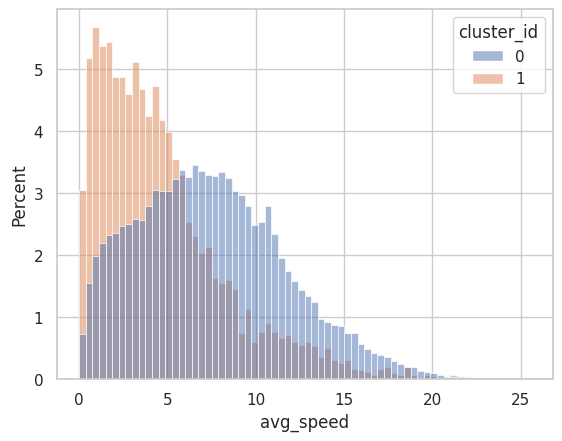

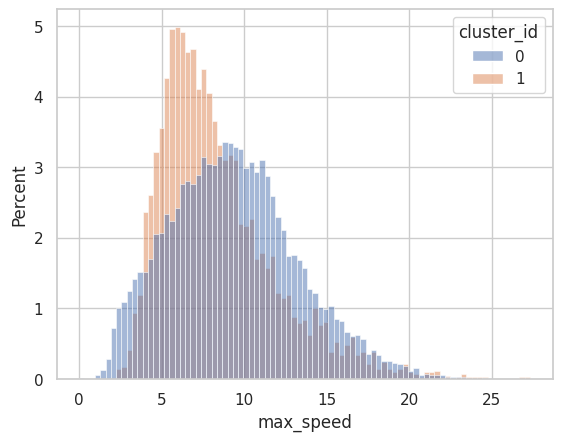

In [79]:
sns.histplot(work_df, x='avg_speed', hue='cluster_id', stat='percent', common_norm=False)
plt.show()
sns.histplot(work_df, x='max_speed', hue='cluster_id', stat='percent', common_norm=False)
plt.show()

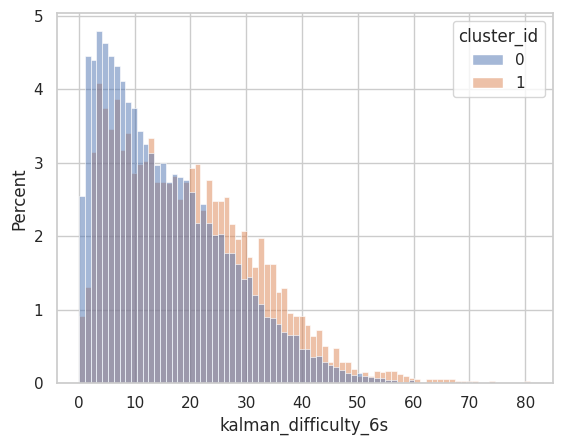

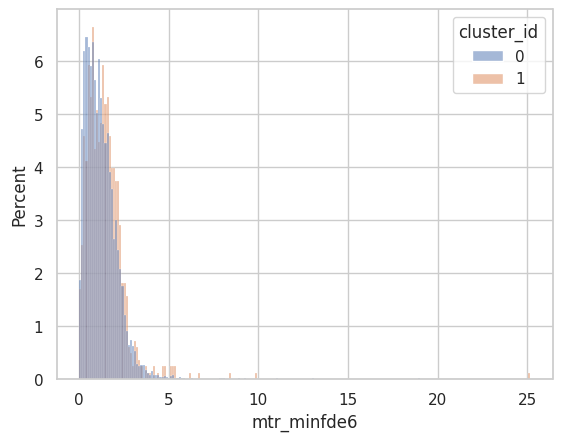

In [83]:
sns.histplot(work_df, x='kalman_difficulty_6s', hue='cluster_id', stat='percent', common_norm=False)
plt.show()
sns.histplot(work_df, x='mtr_minfde6', hue='cluster_id', stat='percent', common_norm=False)
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


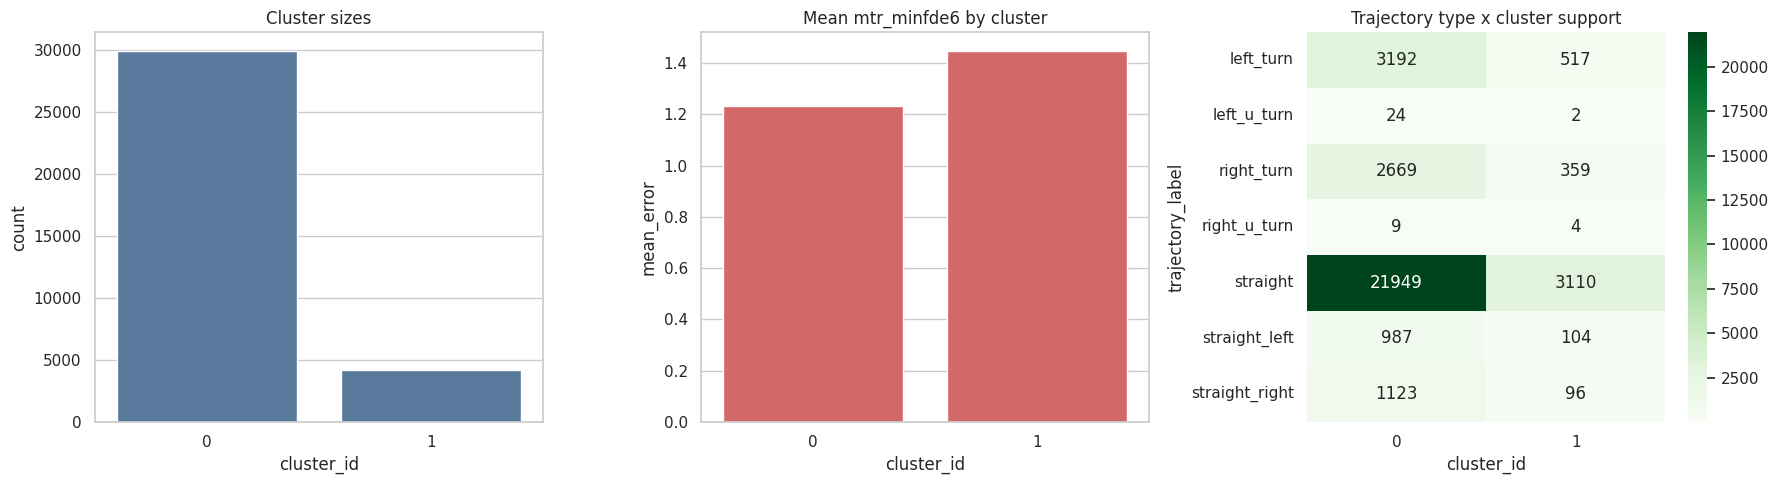

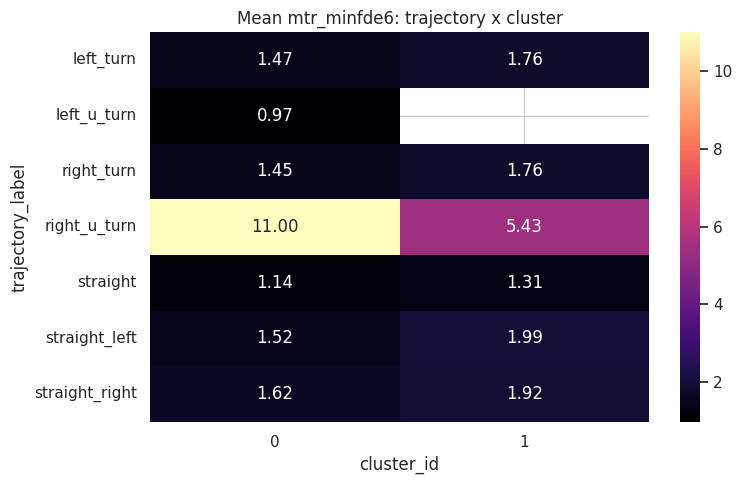

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cluster_summary = work_df.groupby('cluster_id').agg(
    count=('scenario_id', 'size'),
    mean_error=(CONFIG['error_column'], 'mean'),
).reset_index()
sns.barplot(data=cluster_summary, x='cluster_id', y='count', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cluster sizes')
sns.barplot(data=cluster_summary, x='cluster_id', y='mean_error', ax=axes[1], color='#e45756')
axes[1].set_title(f"Mean {CONFIG['error_column']} by cluster")
traj_cluster = work_df.pivot_table(index='trajectory_label', columns='cluster_id', values='scenario_id', aggfunc='count', fill_value=0)
sns.heatmap(traj_cluster, annot=True, fmt='g', cmap='Greens', ax=axes[2])
axes[2].set_title('Trajectory type x cluster support')
plt.tight_layout()
plt.show()

cluster_error = work_df.pivot_table(index='trajectory_label', columns='cluster_id', values=CONFIG['error_column'], aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_error, annot=True, fmt='.2f', cmap='magma')
plt.title(f"Mean {CONFIG['error_column']}: trajectory x cluster")
plt.tight_layout()
plt.show()

In [29]:
sep_importance = separation_feature_importance(work_df, result.labels, feature_names)
loo_importance = leave_one_feature_out_importance(
    df,
    feature_names,
    method=CONFIG['method'],
    n_clusters=CONFIG['n_clusters'],
    transform_mode=CONFIG['transform'],
    clip_mode=CONFIG['clip_mode'],
    error_column=CONFIG['error_column'],
    reference_trajectory_col='trajectory_type',
    reference_label_col=None,
)
display(Markdown('**Cluster separation importance (eta-squared):**'))
display(sep_importance)
display(Markdown('**Leave-one-feature-out importance:**'))
display(loo_importance)

**Cluster separation importance (eta-squared):**

,feature_name,eta_squared,between_ss,total_ss
20,max_abs_heading_delta,0.942740,2.625317e+04,2.784773e+04
21,max_abs_heading_rate,0.942740,2.625317e+06,2.784773e+06
19,heading_change_signed,0.570285,4.973982e+04,8.721929e+04
22,curvature_signed,0.324718,1.102046e+03,3.393858e+03
0,avg_speed,0.229506,1.416395e+05,6.171487e+05
18,path_length,0.222717,4.743473e+06,2.129825e+07
17,displacement,0.220912,4.782546e+06,2.164906e+07
1,max_speed,0.138127,6.989627e+04,5.060306e+05
10,max_abs_long_accel,0.077357,1.040678e+05,1.345292e+06
4,max_accel,0.064081,8.832612e+04,1.378357e+06


**Leave-one-feature-out importance:**

,feature_name,silhouette_drop,error_gap_drop,reduced_silhouette,reduced_error_gap
20,max_abs_heading_delta,0.036982,0.021142,0.683625,0.142885
22,curvature_signed,0.013714,0.006178,0.706894,0.157849
21,max_abs_heading_rate,0.011673,-0.003867,0.708935,0.167894
0,avg_speed,-0.001463,0.000000,0.722070,0.164027
17,displacement,-0.001530,0.000000,0.722137,0.164027
18,path_length,-0.001587,0.000000,0.722194,0.164027
14,max_abs_long_jerk,-0.001762,0.000000,0.722369,0.164027
8,max_abs_jerk,-0.001786,0.000000,0.722393,0.164027
2,var_speed,-0.001788,0.000000,0.722395,0.164027
23,gamma,-0.001841,0.000000,0.722448,0.164027


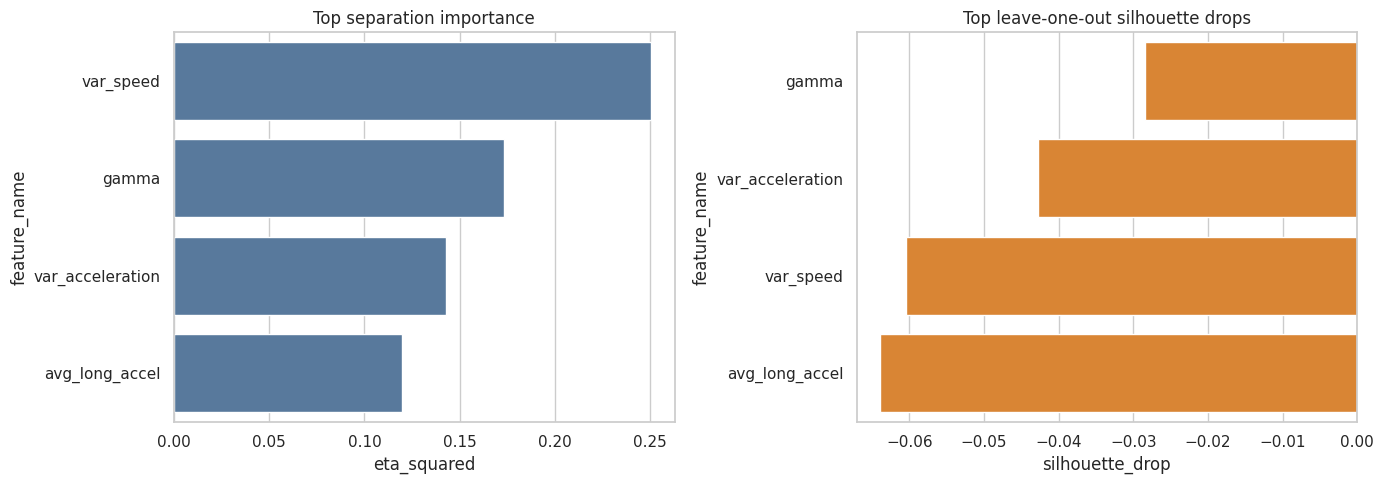

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=sep_importance.head(12), y='feature_name', x='eta_squared', ax=axes[0], color='#4c78a8')
axes[0].set_title('Top separation importance')
sns.barplot(data=loo_importance.head(12), y='feature_name', x='silhouette_drop', ax=axes[1], color='#f58518')
axes[1].set_title('Top leave-one-out silhouette drops')
plt.tight_layout()
plt.show()

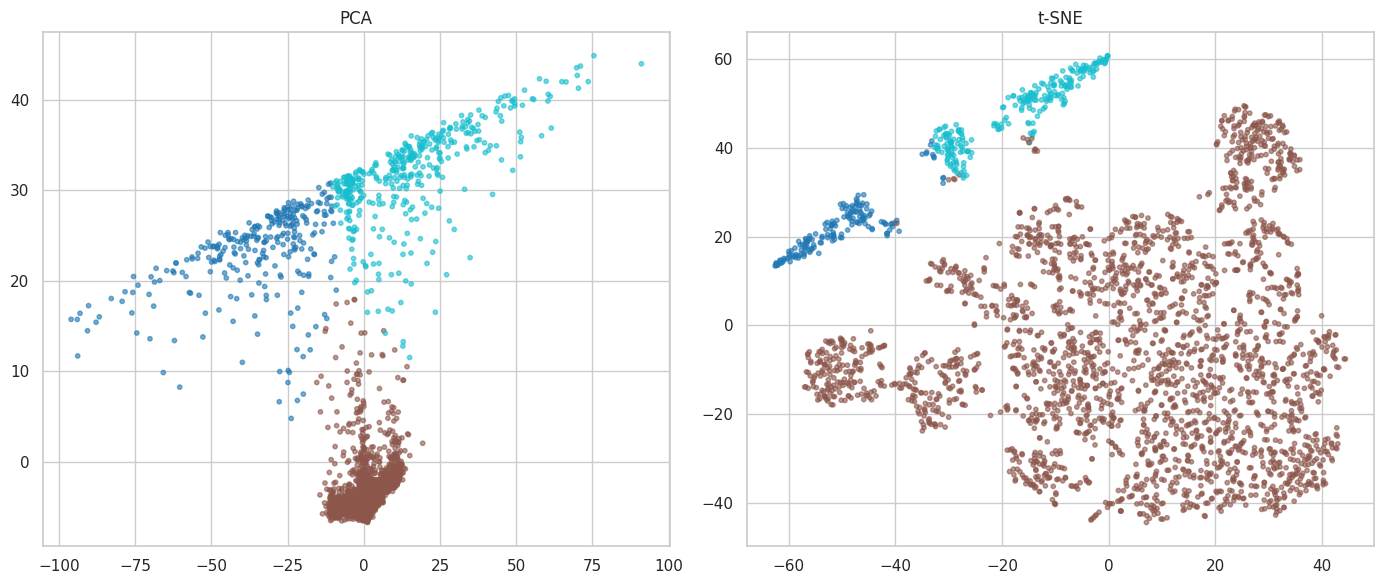

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pca_embed, pca_idx = compute_projection(result.transformed[result.feature_names], method='pca')
axes[0].scatter(pca_embed[:, 0], pca_embed[:, 1], c=work_df.iloc[pca_idx]['cluster_id'], cmap='tab10', s=10, alpha=0.6)
axes[0].set_title('PCA')
tsne_embed, tsne_idx = compute_projection(result.transformed[result.feature_names], method='tsne', sample_limit=CONFIG['tsne_sample_limit'])
axes[1].scatter(tsne_embed[:, 0], tsne_embed[:, 1], c=work_df.iloc[tsne_idx]['cluster_id'], cmap='tab10', s=10, alpha=0.6)
axes[1].set_title('t-SNE')
plt.tight_layout()
plt.show()

In [ ]:
style_sweep = run_feature_sweep(
    df,
    DRIVING_STYLE_FEATURE_SETS,
    methods=CONFIG['feature_sweep_methods'],
    transforms=CONFIG['feature_sweep_transforms'],
    clip_modes=CONFIG['feature_sweep_clip_modes'],
    n_clusters_list=CONFIG['feature_sweep_cluster_counts'],
    error_column=CONFIG['error_column'],
    reference_trajectory_col='trajectory_type',
    reference_label_col=None,
)
display(style_sweep.head(30))


In [33]:
representatives = representative_examples(work_df, result.labels, result.distances, error_column=CONFIG['error_column'])
display(representatives[['cluster_id', 'mode', 'scenario_id', 'center_objects_id', 'trajectory_label', CONFIG['error_column'], 'cluster_distance']].head(30))

cluster_df = representatives[representatives['cluster_id'] == CONFIG['cluster_id']]
mode_df = cluster_df[cluster_df['mode'] == CONFIG['example_mode']]
if CONFIG['scenario_id'] is not None:
    candidate = representatives[representatives['scenario_id'] == CONFIG['scenario_id']].iloc[0]
else:
    candidate = mode_df.iloc[min(CONFIG['example_rank'], max(len(mode_df) - 1, 0))] if len(mode_df) else representatives.iloc[0]

split_name = 'train' if CONFIG['split'] == 'train' else ('validation' if CONFIG['dataset'] == 'waymo' else 'val')
bundle = load_scenario_by_id(CONFIG['dataset'], candidate['scenario_id'], split=split_name)
fig, ax = plot_scenario(bundle['scenario'], dataset=CONFIG['dataset'], view_radius=CONFIG['view_radius'])
plt.show()
display(candidate.to_frame().T)


,cluster_id,mode,scenario_id,center_objects_id,trajectory_label,proxy_fde,cluster_distance
0,0,nearest,4311c290-8fc7-4972-95c5-3276621abf83,145901,straight,8.635378,0.089709
1,0,nearest,06f841ac-58b8-4d3e-9c7d-c1cd67c1b6d3,123119,straight,6.183059,0.105141
2,0,nearest,197dbb4e-b6ab-406e-9bb2-a11a464e7c84,20746,left_turn,14.849862,0.117003
3,0,hardest,780bba4e-fb54-4a46-8ac0-3709f18ad0f6,26369,left_turn,59.563778,0.750614
4,0,hardest,9b4cefa2-d10c-4ee0-a503-a64ab8f35aa2,53209,straight,54.601276,0.630598
5,0,hardest,9a8ff0b7-8b3f-4185-80b6-8a47038f640b,81118,left_turn,53.807522,1.510646
6,0,easiest,e3e8f64c-c4c3-44b1-b881-67ca7fb03cfe,69847,stationary,0.001132,1.448180
7,0,easiest,af1eba11-5f72-4377-b42a-8d1ef2d71be5,39046,stationary,0.001812,1.448180
8,0,easiest,cb70491a-ee4b-4572-aaac-18dae7d3be7b,164524,stationary,0.002013,1.448180
9,1,nearest,d6562d94-65d2-4d7b-bdfb-5f585228662d,24116,straight,6.612350,0.124257


ModuleNotFoundError: No module named 'numpy._core'